# ch251 — Binomial Distribution

**Part VIII: Probability** | Computational Mathematics for Programmers

---

## 1. The Setup: n Independent Binary Trials

You have n independent experiments, each with probability p of "success" and (1−p) of "failure". How many successes do you get?

This is the **binomial distribution**: X ~ Binomial(n, p).

Examples:
- Flip 10 coins. How many heads? X ~ Binomial(10, 0.5)
- Test 100 users. How many convert? X ~ Binomial(100, 0.03)
- Read 8 bits. How many are flipped by noise? X ~ Binomial(8, 0.01)

---

## 2. Derivation of the PMF

P(exactly k successes in n trials):

- The probability of any specific arrangement with k successes and (n−k) failures is p^k · (1−p)^(n−k) (independence).
- The number of such arrangements is C(n,k) = n! / (k!(n−k)!) — the binomial coefficient.

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \quad k = 0, 1, \ldots, n$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from math import comb

def binomial_pmf(n, p, k):
    """P(X=k) for X ~ Binomial(n, p). Implemented from scratch."""
    return comb(n, k) * (p ** k) * ((1 - p) ** (n - k))


# Verify against scipy
n, p = 10, 0.3
for k in range(n + 1):
    ours = binomial_pmf(n, p, k)
    scipy_val = stats.binom.pmf(k, n, p)
    match = np.isclose(ours, scipy_val)
    print(f"P(X={k:2d}) = {ours:.6f}  scipy={scipy_val:.6f}  match={match}")

P(X= 0) = 0.028248  scipy=0.028248  match=True
P(X= 1) = 0.121061  scipy=0.121061  match=True
P(X= 2) = 0.233474  scipy=0.233474  match=True
P(X= 3) = 0.266828  scipy=0.266828  match=True
P(X= 4) = 0.200121  scipy=0.200121  match=True
P(X= 5) = 0.102919  scipy=0.102919  match=True
P(X= 6) = 0.036757  scipy=0.036757  match=True
P(X= 7) = 0.009002  scipy=0.009002  match=True
P(X= 8) = 0.001447  scipy=0.001447  match=True
P(X= 9) = 0.000138  scipy=0.000138  match=True
P(X=10) = 0.000006  scipy=0.000006  match=True


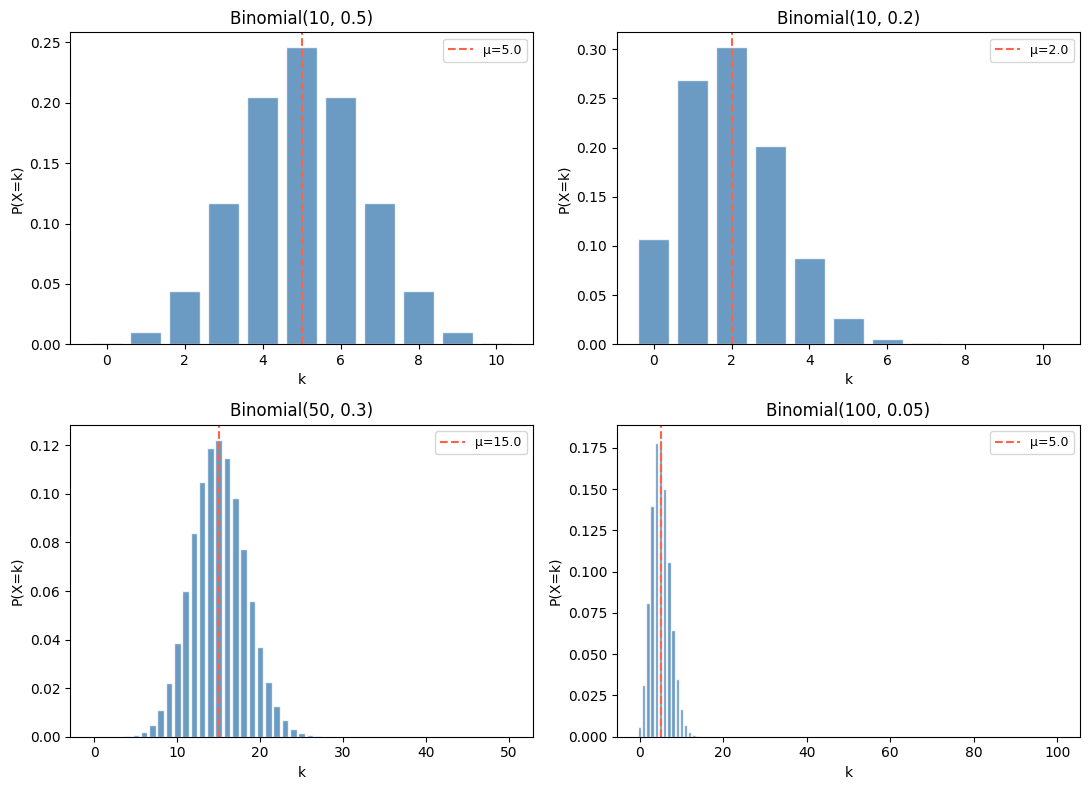

In [2]:
# Visualize for different parameters
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
configs = [
    (10, 0.5, 'Binomial(10, 0.5)'),
    (10, 0.2, 'Binomial(10, 0.2)'),
    (50, 0.3, 'Binomial(50, 0.3)'),
    (100, 0.05, 'Binomial(100, 0.05)'),
]

for ax, (n, p, title) in zip(axes.flat, configs):
    k = np.arange(0, n + 1)
    pmf = stats.binom.pmf(k, n, p)
    mu = n * p
    sigma = np.sqrt(n * p * (1 - p))
    
    ax.bar(k, pmf, color='steelblue', alpha=0.8, edgecolor='white')
    ax.axvline(mu, color='tomato', linestyle='--', label=f'μ={mu:.1f}')
    ax.set_title(title)
    ax.set_xlabel('k')
    ax.set_ylabel('P(X=k)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 3. Mean and Variance

For X ~ Binomial(n, p):
$$E[X] = np$$
$$\text{Var}(X) = np(1-p)$$

*Proof via linearity of expectation*: X = X₁ + X₂ + ... + Xₙ where each Xᵢ ~ Bernoulli(p). E[Xᵢ] = p, Var(Xᵢ) = p(1−p). By linearity and independence: E[X] = np, Var(X) = np(1−p).

In [3]:
def binomial_stats(n, p):
    mu = n * p
    var = n * p * (1 - p)
    return mu, var

configs = [(10, 0.5), (50, 0.3), (100, 0.05)]
print(f"{'n':>6} {'p':>6} {'E[X]=np':>12} {'Var=np(1-p)':>14} {'σ':>8}")
print("-" * 50)
for n, p in configs:
    mu, var = binomial_stats(n, p)
    # Verify with scipy
    rv = stats.binom(n, p)
    assert np.isclose(rv.mean(), mu) and np.isclose(rv.var(), var)
    print(f"{n:>6} {p:>6.2f} {mu:>12.4f} {var:>14.4f} {np.sqrt(var):>8.4f}")

     n      p      E[X]=np    Var=np(1-p)        σ
--------------------------------------------------
    10   0.50       5.0000         2.5000   1.5811
    50   0.30      15.0000        10.5000   3.2404
   100   0.05       5.0000         4.7500   2.1794


## 4. Applications

### A/B Testing

You run an experiment: 200 users see variant A, 200 see variant B. Variant A has 24 conversions, variant B has 34. Is B actually better, or is this variance?

In [4]:
# Under H₀: both have p=0.14 (pooled rate)
n_A, k_A = 200, 24
n_B, k_B = 200, 34

p_A = k_A / n_A
p_B = k_B / n_B
p_pool = (k_A + k_B) / (n_A + n_B)

print(f"Conversion rate A: {p_A:.4f}")
print(f"Conversion rate B: {p_B:.4f}")
print(f"Pooled rate: {p_pool:.4f}")

# P(getting >= 34 conversions under H₀) — one-sided
# Under H₀, k_B ~ Binomial(200, p_pool)
p_value = 1 - stats.binom.cdf(k_B - 1, n_B, p_pool)
print(f"\nP(X >= {k_B} | p={p_pool:.4f}) = {p_value:.4f}")
print(f"Conclusion: {'Significant at α=0.05' if p_value < 0.05 else 'Not significant at α=0.05'}")

Conversion rate A: 0.1200
Conversion rate B: 0.1700
Pooled rate: 0.1450

P(X >= 34 | p=0.1450) = 0.1818
Conclusion: Not significant at α=0.05


## 5. Binomial → Normal Approximation

For large n, Binomial(n, p) is well-approximated by Normal(np, np(1−p)). This is an instance of the Central Limit Theorem *(ch254)*.

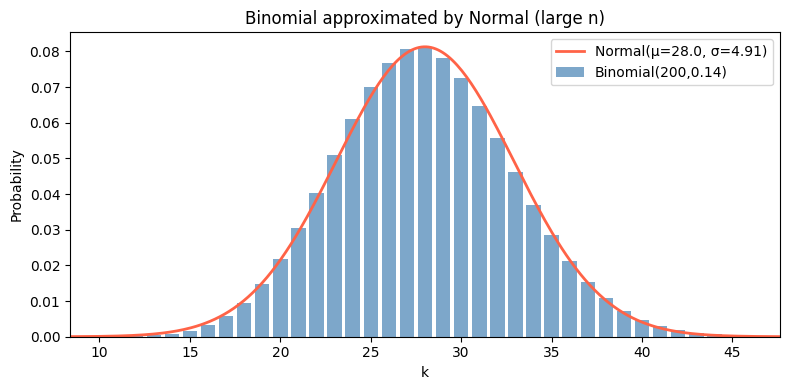

In [5]:
n, p = 200, 0.14
mu, var = n * p, n * p * (1 - p)
sigma = np.sqrt(var)

k = np.arange(0, n + 1)
binom_pmf = stats.binom.pmf(k, n, p)

x_norm = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
norm_pdf = stats.norm.pdf(x_norm, mu, sigma)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(k, binom_pmf, color='steelblue', alpha=0.7, label=f'Binomial({n},{p})')
ax.plot(x_norm, norm_pdf, 'tomato', linewidth=2, label=f'Normal(μ={mu:.1f}, σ={sigma:.2f})')
ax.set_xlim(mu - 4*sigma, mu + 4*sigma)
ax.set_xlabel('k')
ax.set_ylabel('Probability')
ax.set_title('Binomial approximated by Normal (large n)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Summary

- X ~ Binomial(n, p): count of successes in n independent Bernoulli(p) trials.
- PMF: P(X=k) = C(n,k) · p^k · (1−p)^(n−k).
- E[X] = np, Var(X) = np(1−p) — derived via linearity from Bernoulli components.
- For large n: approximates Normal(np, np(1−p)) by the Central Limit Theorem.

---

## 7. Forward References

The Poisson distribution (ch252) is the limit of Binomial(n, p) as n→∞ and p→0 with np=λ fixed. It models rare events in large trials. The normal approximation to the binomial is the simplest case of the Central Limit Theorem (ch254), which generalizes it to sums of any independent random variables.